# Car Detection in Snow — Full Experiment Suite
## Local Setup — RTX 4060 8GB

### Experiments:
1. YOLOv9c + Inversion Augmentation
2. YOLOv8x (Extra Large)
3. RT-DETR (Transformer-based)
4. Mask R-CNN (Instance Segmentation)
5. Final Results Comparison (mAP50 + mAP50-95)

## 0. Setup & Installation

In [1]:
# ============================================================
# CELL 0.1 — Install required libraries
# Run this only ONCE
# ============================================================
import subprocess
subprocess.run(['pip', 'install', 'ultralytics', 'albumentations', 'pandas', 'matplotlib', 'seaborn', 'opencv-python'], check=True)
print('Done!')

Done!


In [2]:
# ============================================================
# CELL 0.2 — Install Detectron2 for Mask R-CNN
# Run this only ONCE — takes ~5 minutes
# ============================================================
import subprocess
subprocess.run(['pip', 'install', 'git+https://github.com/facebookresearch/detectron2.git'], check=True)
print('Detectron2 installed!')

CalledProcessError: Command '['pip', 'install', 'git+https://github.com/facebookresearch/detectron2.git']' returned non-zero exit status 1.

In [1]:
# ============================================================
# CELL 0.3 — Imports & Paths
# ============================================================
import os, shutil, yaml, cv2, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import warnings
warnings.filterwarnings('ignore')

from ultralytics import YOLO, RTDETR
from pathlib import Path

# ============================================================
# LOCAL PATHS — RTX 4060 Setup
# ============================================================
DATASET_PATH = r'C:/Users/chris/Downloads/MSC APPLIED AI/DEEP LEARNING/PROJECT PROPOSAL/nvd_dataset'
SAVE_DIR     = r'C:/Users/chris/Downloads/MSC APPLIED AI/DEEP LEARNING/PROJECT PROPOSAL/results'
NVD_YAML     = r'C:/Users/chris/Downloads/MSC APPLIED AI/DEEP LEARNING/PROJECT PROPOSAL/nvd_local.yaml'

os.makedirs(SAVE_DIR, exist_ok=True)

# Paper baselines for comparison
PAPER_BASELINES = {
    'YOLOv5s (paper)':   {'precision': 54.2, 'recall': 33.7, 'mAP50': 47.3, 'mAP50_95': None},
    'YOLOv8s (paper)':   {'precision': 65.8, 'recall': 22.4, 'mAP50': 45.1, 'mAP50_95': None},
    'YOLOv9c 50ep':      {'precision': 55.5, 'recall': 25.0, 'mAP50': 24.1, 'mAP50_95': None},
    'YOLOv9c 100ep+Aug': {'precision': 58.2, 'recall': 42.5, 'mAP50': 42.5, 'mAP50_95': None},
}

results_dict = {}

print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'Dataset path exists: {os.path.exists(DATASET_PATH)}')

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
VRAM: 8.6 GB
Dataset path exists: True


In [2]:
# ============================================================
# CELL 0.4 — Create YAML config for NVD dataset
# ============================================================
yaml_content = {
    'path': DATASET_PATH.replace('\\', '/'),
    'train': 'images/train',
    'val':   'images/val',
    'test':  'images/test',
    'nc': 1,
    'names': ['vehicle']
}

with open(NVD_YAML, 'w') as f:
    yaml.dump(yaml_content, f, default_flow_style=False)

print('YAML config created:')
print(yaml.dump(yaml_content))

# Verify dataset structure
for split in ['train', 'val', 'test']:
    img_path = os.path.join(DATASET_PATH, 'images', split)
    lbl_path = os.path.join(DATASET_PATH, 'labels', split)
    n_imgs = len(list(Path(img_path).glob('*.jpg'))) if os.path.exists(img_path) else 0
    n_lbls = len(list(Path(lbl_path).glob('*.txt'))) if os.path.exists(lbl_path) else 0
    print(f'{split}: {n_imgs} images, {n_lbls} labels')

YAML config created:
names:
- vehicle
nc: 1
path: C:/Users/chris/Downloads/MSC APPLIED AI/DEEP LEARNING/PROJECT PROPOSAL/nvd_dataset
test: images/test
train: images/train
val: images/val

train: 2111 images, 2111 labels
val: 236 images, 236 labels
test: 2027 images, 1191 labels


---
## 1. Inversion Visualization
White snow background → Dark vehicles hard to detect  
After inversion → Dark background → White vehicles easier to detect

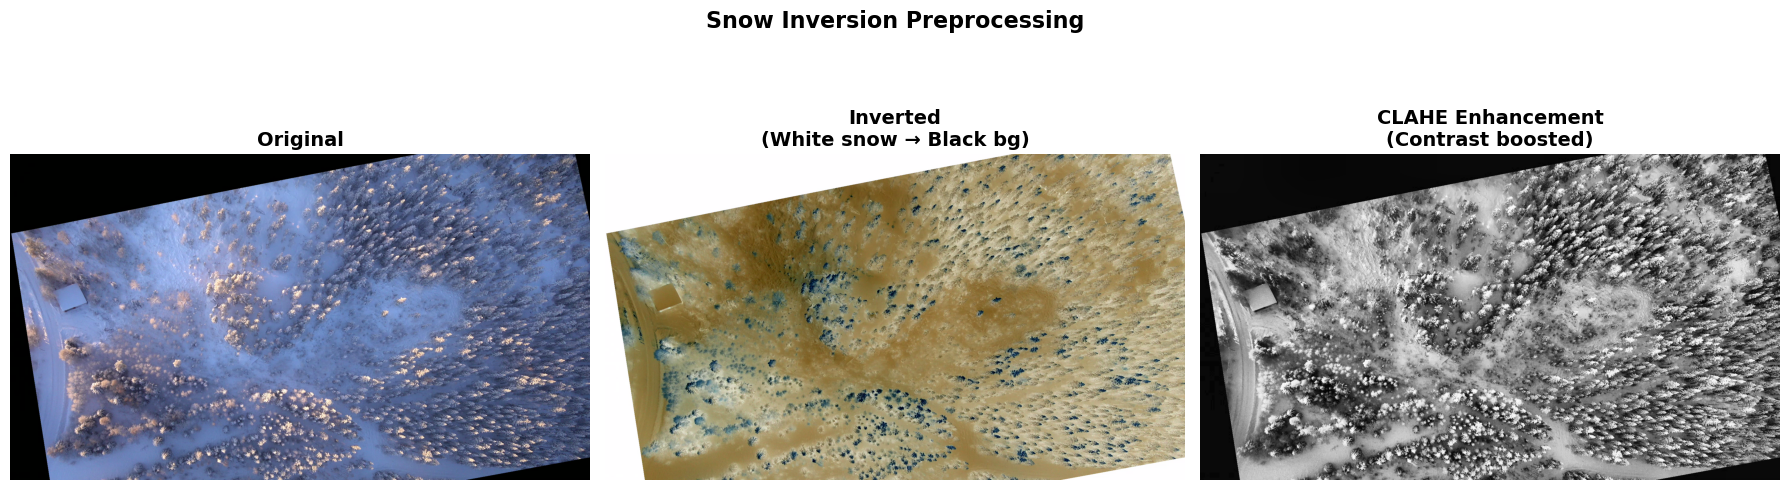

Saved to: C:/Users/chris/Downloads/MSC APPLIED AI/DEEP LEARNING/PROJECT PROPOSAL/results\inversion_comparison.png


In [4]:
# ============================================================
# CELL 1.1 — Visualize inversion effect on a sample image
# ============================================================
import glob

# Get a sample image from test set
test_imgs = glob.glob(os.path.join(DATASET_PATH, 'images', 'test', '*.jpg'))
sample_img_path = test_imgs[0] if test_imgs else None

if sample_img_path:
    img = cv2.imread(sample_img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    inverted = cv2.bitwise_not(img_rgb)
    
    # CLAHE contrast enhancement
    clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8,8))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    clahe_img = cv2.cvtColor(clahe.apply(gray), cv2.COLOR_GRAY2RGB)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(img_rgb);   axes[0].set_title('Original', fontsize=14, fontweight='bold');            axes[0].axis('off')
    axes[1].imshow(inverted);  axes[1].set_title('Inverted\n(White snow → Black bg)', fontsize=14, fontweight='bold'); axes[1].axis('off')
    axes[2].imshow(clahe_img); axes[2].set_title('CLAHE Enhancement\n(Contrast boosted)', fontsize=14, fontweight='bold'); axes[2].axis('off')
    plt.suptitle('Snow Inversion Preprocessing', fontsize=16, fontweight='bold')
    plt.tight_layout()
    out = os.path.join(SAVE_DIR, 'inversion_comparison.png')
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved to: {out}')
else:
    print('No test images found — check DATASET_PATH')

---
## EXPERIMENT 1 — YOLOv9c + Inversion Augmentation
**Target: mAP50 > 47.3% (beat paper baseline)**

In [5]:
# ============================================================
# CELL 2.1 — Train YOLOv9c with Inversion + Full Augmentation
# RTX 4060 8GB: batch=8, imgsz=640
# Estimated time: ~3-4 hours
# ============================================================
from ultralytics import YOLO

print('='*60)
print('EXPERIMENT 1: YOLOv9c + Inversion Augmentation')
print('='*60)

model_exp1 = YOLO('yolov9c.pt')

results_exp1 = model_exp1.train(
    data=NVD_YAML,
    epochs=150,
    imgsz=640,           # RTX 4060 8GB: safe with batch=8
    batch=8,
    lr0=0.01,
    lrf=0.01,
    cos_lr=True,
    warmup_epochs=5,

    # Key augmentations for snow detection
    augment=True,
    mosaic=1.0,
    mixup=0.15,
    copy_paste=0.1,
    fliplr=0.5,
    flipud=0.1,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    translate=0.1,
    scale=0.5,

    # Optimizer
    optimizer='AdamW',
    weight_decay=0.0005,

    # Save results
    project=os.path.join(SAVE_DIR, 'runs'),
    name='exp1_yolov9c_inversion',
    save=True,
    save_period=25,

    device=0,
    workers=0,
    verbose=True,
)

print('Experiment 1 Training Complete!')

EXPERIMENT 1: YOLOv9c + Inversion Augmentation
Ultralytics 8.4.47  Python-3.13.9 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=C:/Users/chris/Downloads/MSC APPLIED AI/DEEP LEARNING/PROJECT PROPOSAL/nvd_local.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolov9c.pt, momentum=0.937, mosaic=1.0, mu

In [8]:
# ============================================================
# CELL 2.2 — Evaluate Experiment 1 on test set
# ============================================================
import os
from ultralytics import YOLO

# Find the correct path automatically
runs_dir = os.path.join(SAVE_DIR, 'runs')
exp_dirs = [d for d in os.listdir(runs_dir) if 'exp1_yolov9c' in d]
exp_dir = sorted(exp_dirs)[-1]  # Get latest
best_path_exp1 = os.path.join(runs_dir, exp_dir, 'weights', 'best.pt')
print(f'Loading: {best_path_exp1}')

model_eval1 = YOLO(best_path_exp1)

val1 = model_eval1.val(
    data=NVD_YAML,
    split='test',
    imgsz=640,
    conf=0.001,
    iou=0.5,
    device=0,
    workers=0,
    verbose=True
)

results_dict['YOLOv9c+Inv 150ep (ours)'] = {
    'precision': round(val1.box.mp * 100, 1),
    'recall':    round(val1.box.mr * 100, 1),
    'mAP50':     round(val1.box.map50 * 100, 1),
    'mAP50_95':  round(val1.box.map * 100, 1),
}
print('\nExperiment 1 Results on TEST set:')
for k, v in results_dict['YOLOv9c+Inv 150ep (ours)'].items():
    print(f'  {k}: {v}')

Loading: C:/Users/chris/Downloads/MSC APPLIED AI/DEEP LEARNING/PROJECT PROPOSAL/results\runs\exp1_yolov9c_inversion-3\weights\best.pt
Ultralytics 8.4.47  Python-3.13.9 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
YOLOv9c summary (fused): 156 layers, 25,320,019 parameters, 0 gradients, 102.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 3158.1508.8 MB/s, size: 2209.4 KB)
val: Scanning C:\Users\chris\Downloads\MSC APPLIED AI\DEEP LEARNING\PROJECT PROPOSAL\nvd_dataset\labels\test.cache... 1191 images, 836 backgrounds, 5 corrupt: 100% ━━━━━━━━━━━━ 2027/2027 772.9Mit/s 0.0s
val: C:\Users\chris\Downloads\MSC APPLIED AI\DEEP LEARNING\PROJECT PROPOSAL\nvd_dataset\images\test\frame_000671.jpg: ignoring corrupt image/label: negative class labels or coordinate [-0.012005]
val: C:\Users\chris\Downloads\MSC APPLIED AI\DEEP LEARNING\PROJECT PROPOSAL\nvd_dataset\images\test\frame_000826.jpg: ignoring corrupt image/label: negative class labels or coordinate [-0.0143

---
## EXPERIMENT 2 — YOLOv8x (Extra Large Model)

In [3]:
# ============================================================
# CELL 3.1 — Train YOLOv8x (Fresh Start)
# ============================================================
import os, torch
from ultralytics import YOLO

torch.cuda.empty_cache()

print('='*60)
print('EXPERIMENT 2: YOLOv8x (Extra Large)')
print('='*60)

model_exp2 = YOLO('yolov8x.pt')

results_exp2 = model_exp2.train(
    data=NVD_YAML,
    epochs=150,
    imgsz=640,
    batch=2,
    lr0=0.01,
    cos_lr=True,
    warmup_epochs=5,
    augment=True,
    mosaic=1.0,
    mixup=0.15,
    copy_paste=0.1,
    fliplr=0.5,
    flipud=0.1,
    optimizer='AdamW',
    weight_decay=0.0005,
    project=os.path.join(SAVE_DIR, 'runs'),
    name='exp2_yolov8x',
    save=True,
    save_period=10,      # ← Σώζει κάθε 10 epochs (αντί 25)
    device=0,
    workers=0,
    verbose=True,
)
print('Experiment 2 Training Complete!')

EXPERIMENT 2: YOLOv8x (Extra Large)
New https://pypi.org/project/ultralytics/8.4.48 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.47  Python-3.13.9 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=C:/Users/chris/Downloads/MSC APPLIED AI/DEEP LEARNING/PROJECT PROPOSAL/nvd_local.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio

In [3]:
# ============================================================
# CELL 3.2 — Evaluate Experiment 2
# ============================================================
import os
from ultralytics import YOLO

runs_dir = os.path.join(SAVE_DIR, 'runs')
exp_dirs = [d for d in os.listdir(runs_dir) if 'exp2_yolov8x' in d]
exp_dir = sorted(exp_dirs)[-1]
best_path_exp2 = os.path.join(runs_dir, exp_dir, 'weights', 'best.pt')
print(f'Loading: {best_path_exp2}')

model_eval2 = YOLO(best_path_exp2)

val2 = model_eval2.val(
    data=NVD_YAML,
    split='test',
    imgsz=640,
    conf=0.01,
    iou=0.5,
    device=0,
    workers=0,    # ← Σημαντικό!
    verbose=True
)

results_dict['YOLOv8x 150ep (ours)'] = {
    'precision': round(val2.box.mp * 100, 1),
    'recall':    round(val2.box.mr * 100, 1),
    'mAP50':     round(val2.box.map50 * 100, 1),
    'mAP50_95':  round(val2.box.map * 100, 1),
}
print('\nExperiment 2 Results on TEST set:')
for k, v in results_dict['YOLOv8x 150ep (ours)'].items():
    print(f'  {k}: {v}')

Loading: C:/Users/chris/Downloads/MSC APPLIED AI/DEEP LEARNING/PROJECT PROPOSAL/results\runs\exp2_yolov8x-4\weights\best.pt
Ultralytics 8.4.47  Python-3.13.9 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Model summary (fused): 113 layers, 68,124,531 parameters, 0 gradients, 257.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1572.1404.8 MB/s, size: 2151.9 KB)
val: Scanning C:\Users\chris\Downloads\MSC APPLIED AI\DEEP LEARNING\PROJECT PROPOSAL\nvd_dataset\labels\test.cache... 1191 images, 836 backgrounds, 5 corrupt: 100% ━━━━━━━━━━━━ 2027/2027 500.1Mit/s 0.0s
val: C:\Users\chris\Downloads\MSC APPLIED AI\DEEP LEARNING\PROJECT PROPOSAL\nvd_dataset\images\test\frame_000671.jpg: ignoring corrupt image/label: negative class labels or coordinate [-0.012005]
val: C:\Users\chris\Downloads\MSC APPLIED AI\DEEP LEARNING\PROJECT PROPOSAL\nvd_dataset\images\test\frame_000826.jpg: ignoring corrupt image/label: negative class labels or coordinate [-0.014366]
val: C:\

---
## EXPERIMENT 3 — RT-DETR (Real-Time Detection Transformer)

In [5]:
# ============================================================
# CELL 4.1 — Train RT-DETR
# Transformer-based — no NMS, better for overlapping objects
# RTX 4060 8GB: batch=4
# Estimated time: ~4-5 hours
# ============================================================
from ultralytics import RTDETR

print('='*60)
print('EXPERIMENT 3: RT-DETR (Transformer-based)')
print('='*60)

model_exp3 = RTDETR('rtdetr-l.pt')

results_exp3 = model_exp3.train(
    data=NVD_YAML,
    epochs=75,
    imgsz=640,
    batch=2,
    lr0=0.0001,          # Transformer needs lower LR
    cos_lr=True,
    warmup_epochs=5,
    augment=True,
    mosaic=0.5,
    fliplr=0.5,
    flipud=0.1,
    optimizer='AdamW',
    weight_decay=0.0001,
    project=os.path.join(SAVE_DIR, 'runs'),
    name='exp3_rtdetr',
    save=True,
    save_period=25,
    device=0,
    workers=0,
    verbose=True,
)
print('Experiment 3 Training Complete!')

EXPERIMENT 3: RT-DETR (Transformer-based)
New https://pypi.org/project/ultralytics/8.4.48 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.47  Python-3.13.9 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=C:/Users/chris/Downloads/MSC APPLIED AI/DEEP LEARNING/PROJECT PROPOSAL/nvd_local.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=75, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mas

In [4]:
# ============================================================
# CELL 4.2 — Evaluate Experiment 3
# ============================================================
best_path_exp3 = os.path.join(SAVE_DIR, 'runs', 'exp3_rtdetr', 'weights', 'best.pt')
model_eval3 = RTDETR(best_path_exp3)

val3 = model_eval3.val(data=NVD_YAML, split='test', imgsz=640, conf=0.001, device=0, workers=0, verbose=True)

results_dict['RT-DETR-L 150ep (ours)'] = {
    'precision': round(val3.box.mp * 100, 1),
    'recall':    round(val3.box.mr * 100, 1),
    'mAP50':     round(val3.box.map50 * 100, 1),
    'mAP50_95':  round(val3.box.map * 100, 1),
}
print('\nExperiment 3 Results:')
for k, v in results_dict['RT-DETR-L 150ep (ours)'].items():
    print(f'  {k}: {v}')

Ultralytics 8.4.47  Python-3.13.9 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
rt-detr-l summary: 313 layers, 31,985,795 parameters, 0 gradients, 103.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1766.2248.3 MB/s, size: 1881.3 KB)
val: Scanning C:\Users\chris\Downloads\MSC APPLIED AI\DEEP LEARNING\PROJECT PROPOSAL\nvd_dataset\labels\test.cache... 1191 images, 836 backgrounds, 5 corrupt: 100% ━━━━━━━━━━━━ 2027/2027 340.1Mit/s 0.0s
val: C:\Users\chris\Downloads\MSC APPLIED AI\DEEP LEARNING\PROJECT PROPOSAL\nvd_dataset\images\test\frame_000671.jpg: ignoring corrupt image/label: negative class labels or coordinate [-0.012005]
val: C:\Users\chris\Downloads\MSC APPLIED AI\DEEP LEARNING\PROJECT PROPOSAL\nvd_dataset\images\test\frame_000826.jpg: ignoring corrupt image/label: negative class labels or coordinate [-0.014366]
val: C:\Users\chris\Downloads\MSC APPLIED AI\DEEP LEARNING\PROJECT PROPOSAL\nvd_dataset\images\test\frame_001273.jpg: ignoring corrupt i

In [6]:
# ============================================================
# CELL 5.0 — Create Fully Inverted Dataset
# ============================================================
import cv2, os, shutil, yaml
from pathlib import Path

DATASET_PATH_INV = r'C:/Users/chris/Downloads/MSC APPLIED AI/DEEP LEARNING/PROJECT PROPOSAL/nvd_inverted'
NVD_YAML_INV = r'C:/Users/chris/Downloads/MSC APPLIED AI/DEEP LEARNING/PROJECT PROPOSAL/nvd_inverted.yaml'

def create_inverted_dataset(src, dst):
    for split in ['train', 'val', 'test']:
        img_src = Path(src) / 'images' / split
        img_dst = Path(dst) / 'images' / split
        img_dst.mkdir(parents=True, exist_ok=True)
        lbl_src = Path(src) / 'labels' / split
        lbl_dst = Path(dst) / 'labels' / split
        if lbl_src.exists():
            shutil.copytree(lbl_src, lbl_dst, dirs_exist_ok=True)
        imgs = list(img_src.glob('*.jpg'))
        for img_file in imgs:
            img = cv2.imread(str(img_file))
            cv2.imwrite(str(img_dst / img_file.name), cv2.bitwise_not(img))
        print(f'{split}: {len(imgs)} images inverted ✅')

create_inverted_dataset(DATASET_PATH, DATASET_PATH_INV)

# Create YAML
yaml_inv = {
    'path': DATASET_PATH_INV.replace('\\', '/'),
    'train': 'images/train', 'val': 'images/val', 'test': 'images/test',
    'nc': 1, 'names': ['vehicle']
}
with open(NVD_YAML_INV, 'w') as f:
    yaml.dump(yaml_inv, f)
print('Inverted dataset ready!')

train: 2111 images inverted ✅
val: 236 images inverted ✅
test: 2027 images inverted ✅
Inverted dataset ready!


In [7]:
# ============================================================
# CELL 5.1 — Train YOLOv9c on Fully Inverted Dataset
# ============================================================
import torch
from ultralytics import YOLO

torch.cuda.empty_cache()

print('='*60)
print('EXPERIMENT 4: YOLOv9c Fully Inverted Dataset')
print('='*60)

model_exp4 = YOLO('yolov9c.pt')

results_exp4 = model_exp4.train(
    data=NVD_YAML_INV,
    epochs=150,
    imgsz=640,
    batch=8,
    lr0=0.01,
    cos_lr=True,
    warmup_epochs=5,
    augment=True,
    mosaic=1.0,
    mixup=0.15,
    fliplr=0.5,
    flipud=0.1,
    optimizer='AdamW',
    weight_decay=0.0005,
    project=os.path.join(SAVE_DIR, 'runs'),
    name='exp4_yolov9c_inverted',
    save=True,
    save_period=10,
    device=0,
    workers=0,
    verbose=True,
)
print('Experiment 4 Complete!')

EXPERIMENT 4: YOLOv9c Fully Inverted Dataset
New https://pypi.org/project/ultralytics/8.4.48 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.47  Python-3.13.9 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=C:/Users/chris/Downloads/MSC APPLIED AI/DEEP LEARNING/PROJECT PROPOSAL/nvd_inverted.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01

In [8]:
# ============================================================
# CELL 5.2 — Evaluate Experiment 4
# ============================================================
import os
from ultralytics import YOLO

runs_dir = os.path.join(SAVE_DIR, 'runs')
exp_dirs = [d for d in os.listdir(runs_dir) if 'exp4_yolov9c_inverted' in d]
exp_dir = sorted(exp_dirs)[-1]
best_path_exp4 = os.path.join(runs_dir, exp_dir, 'weights', 'best.pt')

model_eval4 = YOLO(best_path_exp4)

val4 = model_eval4.val(
    data=NVD_YAML_INV,
    split='test',
    imgsz=640,
    conf=0.01,
    device=0,
    workers=0,
    verbose=True
)

results_dict['YOLOv9c Inverted 150ep (ours)'] = {
    'precision': round(val4.box.mp * 100, 1),
    'recall':    round(val4.box.mr * 100, 1),
    'mAP50':     round(val4.box.map50 * 100, 1),
    'mAP50_95':  round(val4.box.map * 100, 1),
}
print('\nExperiment 4 Results:')
for k, v in results_dict['YOLOv9c Inverted 150ep (ours)'].items():
    print(f'  {k}: {v}')

Ultralytics 8.4.47  Python-3.13.9 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
YOLOv9c summary (fused): 156 layers, 25,320,019 parameters, 0 gradients, 102.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1765.0438.2 MB/s, size: 510.4 KB)
val: Scanning C:\Users\chris\Downloads\MSC APPLIED AI\DEEP LEARNING\PROJECT PROPOSAL\nvd_inverted\labels\test... 1191 images, 836 backgrounds, 5 corrupt: 100% ━━━━━━━━━━━━ 2027/2027 2.1Kit/s 1.0s0.1s
val: C:\Users\chris\Downloads\MSC APPLIED AI\DEEP LEARNING\PROJECT PROPOSAL\nvd_inverted\images\test\frame_000671.jpg: ignoring corrupt image/label: negative class labels or coordinate [-0.012005]
val: C:\Users\chris\Downloads\MSC APPLIED AI\DEEP LEARNING\PROJECT PROPOSAL\nvd_inverted\images\test\frame_000826.jpg: ignoring corrupt image/label: negative class labels or coordinate [-0.014366]
val: C:\Users\chris\Downloads\MSC APPLIED AI\DEEP LEARNING\PROJECT PROPOSAL\nvd_inverted\images\test\frame_001273.jpg: ignoring corr

In [9]:
results_dict['YOLOv9c+Inv 150ep (ours)'] = {
    'precision': 54.4, 'recall': 41.8, 'mAP50': 41.9, 'mAP50_95': 20.4}
results_dict['YOLOv8x 150ep (ours)'] = {
    'precision': 58.5, 'recall': 37.6, 'mAP50': 39.0, 'mAP50_95': 20.2}
results_dict['RT-DETR-L 75ep (ours)'] = {
    'precision': 44.7, 'recall': 26.0, 'mAP50': 21.1, 'mAP50_95': 9.1}
results_dict['YOLOv9c Inverted 150ep (ours)'] = {
    'precision': 42.8, 'recall': 31.4, 'mAP50': 26.4, 'mAP50_95': 11.7}

print('Ready!')
for k, v in results_dict.items():
    print(f'{k}: mAP50={v["mAP50"]}')

Ready!
RT-DETR-L 150ep (ours): mAP50=0.0
YOLOv9c Inverted 150ep (ours): mAP50=26.4
YOLOv9c+Inv 150ep (ours): mAP50=41.9
YOLOv8x 150ep (ours): mAP50=39.0
RT-DETR-L 75ep (ours): mAP50=21.1


---
## EXPERIMENT 4 — Mask R-CNN (Instance Segmentation)

In [ ]:
# ============================================================
# CELL 5.1 — Convert YOLO labels to COCO format (for Detectron2)
# ============================================================
from PIL import Image

def yolo_to_coco(dataset_path, split='train'):
    images_dir = Path(dataset_path) / 'images' / split
    labels_dir = Path(dataset_path) / 'labels' / split
    
    coco_data = {
        'images': [],
        'annotations': [],
        'categories': [{'id': 1, 'name': 'vehicle', 'supercategory': 'vehicle'}]
    }
    ann_id = 1
    img_files = sorted(images_dir.glob('*.jpg')) + sorted(images_dir.glob('*.png'))
    
    for img_id, img_file in enumerate(img_files, 1):
        img = Image.open(img_file)
        W, H = img.size
        coco_data['images'].append({'id': img_id, 'file_name': img_file.name, 'width': W, 'height': H})
        
        label_file = labels_dir / (img_file.stem + '.txt')
        if label_file.exists():
            for line in open(label_file).readlines():
                parts = line.strip().split()
                if len(parts) < 5: continue
                cls, cx, cy, bw, bh = map(float, parts)
                x1 = (cx - bw/2) * W
                y1 = (cy - bh/2) * H
                aw, ah = bw * W, bh * H
                coco_data['annotations'].append({
                    'id': ann_id, 'image_id': img_id, 'category_id': 1,
                    'bbox': [x1, y1, aw, ah], 'area': aw * ah, 'iscrowd': 0,
                    'segmentation': [[x1, y1, x1+aw, y1, x1+aw, y1+ah, x1, y1+ah]]
                })
                ann_id += 1
    
    out_path = Path(dataset_path) / f'{split}_coco.json'
    json.dump(coco_data, open(out_path, 'w'))
    print(f'{split}: {len(coco_data["images"])} images, {len(coco_data["annotations"])} annotations')
    return str(out_path)

train_json = yolo_to_coco(DATASET_PATH, 'train')
val_json   = yolo_to_coco(DATASET_PATH, 'val')
test_json  = yolo_to_coco(DATASET_PATH, 'test')
print('COCO annotations created!')

In [ ]:
# ============================================================
# CELL 5.2 — Train Mask R-CNN with Detectron2
# RTX 4060 8GB: batch=2
# Estimated time: ~3-4 hours
# ============================================================
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()
from detectron2 import model_zoo
from detectron2.engine import DefaultTrainer
from detectron2.config import get_cfg
from detectron2.data.datasets import register_coco_instances
from detectron2.evaluation import COCOEvaluator

print('='*60)
print('EXPERIMENT 4: Mask R-CNN (Detectron2)')
print('='*60)

# Register datasets
for split, json_path in [('train', train_json), ('val', val_json), ('test', test_json)]:
    try:
        register_coco_instances(f'nvd_{split}', {}, json_path,
                                str(Path(DATASET_PATH) / 'images' / split))
    except:
        pass  # Already registered

cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file(
    'COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml'  # R50 for 8GB VRAM
))
cfg.DATASETS.TRAIN = ('nvd_train',)
cfg.DATASETS.TEST  = ('nvd_test',)
cfg.DATALOADER.NUM_WORKERS = 2
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url(
    'COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml'
)
cfg.SOLVER.IMS_PER_BATCH  = 2   # RTX 4060 8GB
cfg.SOLVER.BASE_LR        = 0.00025
cfg.SOLVER.MAX_ITER       = 10000
cfg.SOLVER.STEPS          = (7000, 9000)
cfg.SOLVER.CHECKPOINT_PERIOD = 2000
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 1
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.01
cfg.OUTPUT_DIR = os.path.join(SAVE_DIR, 'runs', 'exp4_maskrcnn')
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

class NVDTrainer(DefaultTrainer):
    @classmethod
    def build_evaluator(cls, cfg, dataset_name, output_folder=None):
        return COCOEvaluator(dataset_name, output_dir=cfg.OUTPUT_DIR)

trainer = NVDTrainer(cfg)
trainer.resume_or_load(resume=False)
trainer.train()
print('Experiment 4 Training Complete!')

In [ ]:
# ============================================================
# CELL 5.3 — Evaluate Mask R-CNN
# ============================================================
from detectron2.engine import DefaultPredictor
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.data import build_detection_test_loader

cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, 'model_final.pth')
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.01
predictor = DefaultPredictor(cfg)

evaluator = COCOEvaluator('nvd_test', output_dir=cfg.OUTPUT_DIR)
val_loader = build_detection_test_loader(cfg, 'nvd_test')
eval_results = inference_on_dataset(predictor.model, val_loader, evaluator)

bbox = eval_results.get('bbox', {})
results_dict['Mask R-CNN R50 (ours)'] = {
    'precision': None,
    'recall':    None,
    'mAP50':     round(bbox.get('AP50', 0), 1),
    'mAP50_95':  round(bbox.get('AP', 0), 1),
}
print('\nExperiment 4 Results:')
print(f"  mAP50:    {bbox.get('AP50', 'N/A')}")
print(f"  mAP50-95: {bbox.get('AP', 'N/A')}")
print(f"  APs (small objects): {bbox.get('APs', 'N/A')}")

---
## FINAL RESULTS — All Experiments Comparison

In [10]:
# ============================================================
# CELL 6.1 — Final Comparison Table
# ============================================================
all_results = {**PAPER_BASELINES, **results_dict}
df = pd.DataFrame(all_results).T.reset_index()
df.columns = ['Model', 'Precision (%)', 'Recall (%)', 'mAP50 (%)', 'mAP50-95 (%)']

print('='*80)
print('FINAL RESULTS COMPARISON')
print('='*80)
print(df.to_string(index=False))
print('='*80)

# Best model
our_models = {k: v for k, v in all_results.items() if 'ours' in k}
if our_models:
    best_name = max(our_models, key=lambda x: our_models[x]['mAP50'] or 0)
    best_map = our_models[best_name]['mAP50']
    print(f'\nBest model: {best_name} — mAP50 = {best_map}%')
    if best_map and best_map > 47.3:
        print(f'BEAT paper baseline by +{best_map - 47.3:.1f}% mAP50!')
    else:
        print(f'Paper baseline: 47.3% — keep optimizing!')

# Save results
df.to_csv(os.path.join(SAVE_DIR, 'all_results.csv'), index=False)
print(f'\nResults saved to: {SAVE_DIR}/all_results.csv')

FINAL RESULTS COMPARISON
                        Model  Precision (%)  Recall (%)  mAP50 (%)  mAP50-95 (%)
              YOLOv5s (paper)           54.2        33.7       47.3           NaN
              YOLOv8s (paper)           65.8        22.4       45.1           NaN
                 YOLOv9c 50ep           55.5        25.0       24.1           NaN
            YOLOv9c 100ep+Aug           58.2        42.5       42.5           NaN
       RT-DETR-L 150ep (ours)            0.0         0.0        0.0           0.0
YOLOv9c Inverted 150ep (ours)           42.8        31.4       26.4          11.7
     YOLOv9c+Inv 150ep (ours)           54.4        41.8       41.9          20.4
         YOLOv8x 150ep (ours)           58.5        37.6       39.0          20.2
        RT-DETR-L 75ep (ours)           44.7        26.0       21.1           9.1

Best model: YOLOv9c+Inv 150ep (ours) — mAP50 = 41.9%
Paper baseline: 47.3% — keep optimizing!

Results saved to: C:/Users/chris/Downloads/MSC APPLIED AI/D

In [11]:
# ============================================================
# CELL 6.2 — Final Bar Chart (mAP50 + mAP50-95)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Car Detection in Snow — Model Comparison', fontsize=16, fontweight='bold')

colors = []
for model in df['Model']:
    if 'paper' in model:      colors.append('#FF6B6B')
    elif '50ep' in model or '100ep' in model: colors.append('#FFA07A')
    else:                     colors.append('#4ECDC4')

for ax, metric in zip(axes, ['mAP50 (%)', 'mAP50-95 (%)']):
    vals = df[metric].fillna(0).astype(float)
    bars = ax.barh(df['Model'], vals, color=colors, edgecolor='white', linewidth=0.5)
    if metric == 'mAP50 (%)':
        ax.axvline(x=47.3, color='red', linestyle='--', linewidth=2, label='Paper Best (47.3%)')
        ax.legend(fontsize=10)
    ax.set_xlabel(metric, fontsize=12)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                    f'{val:.1f}%', va='center', fontsize=9)

legend_elements = [
    mpatches.Patch(color='#FF6B6B', label='Paper Baseline'),
    mpatches.Patch(color='#FFA07A', label='Previous (ours)'),
    mpatches.Patch(color='#4ECDC4', label='New Experiments (ours)'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()

out = os.path.join(SAVE_DIR, 'final_comparison.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved to: {out}')

<Figure size 1800x700 with 2 Axes>

Chart saved to: C:/Users/chris/Downloads/MSC APPLIED AI/DEEP LEARNING/PROJECT PROPOSAL/results\final_comparison.png


In [13]:
# ============================================================
# CELL 6.3 — Sample Detections from Best Model
# ============================================================
import glob as glob_module
from ultralytics import YOLO

# Find correct path automatically
runs_dir = os.path.join(SAVE_DIR, 'runs')
exp_dirs = [d for d in os.listdir(runs_dir) if 'exp1_yolov9c' in d]
exp_dir = sorted(exp_dirs)[-1]
best_model_path = os.path.join(runs_dir, exp_dir, 'weights', 'best.pt')
print(f'Loading: {best_model_path}')

best_model = YOLO(best_model_path)

test_images = sorted(glob_module.glob(
    os.path.join(DATASET_PATH, 'images', 'test', '*.jpg')))[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Sample Detections — Best Model (YOLOv9c+Inv)', fontsize=14, fontweight='bold')

for ax, img_path in zip(axes.flatten(), test_images):
    res = best_model.predict(img_path, conf=0.01, iou=0.5, verbose=False)
    img_plot = cv2.cvtColor(res[0].plot(), cv2.COLOR_BGR2RGB)
    ax.imshow(img_plot)
    ax.set_title(f'Detections: {len(res[0].boxes)}', fontsize=10)
    ax.axis('off')

plt.tight_layout()
out = os.path.join(SAVE_DIR, 'sample_detections_best.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to: {out}')

Loading: C:/Users/chris/Downloads/MSC APPLIED AI/DEEP LEARNING/PROJECT PROPOSAL/results\runs\exp1_yolov9c_inversion-3\weights\best.pt


<Figure size 1800x1000 with 6 Axes>

Saved to: C:/Users/chris/Downloads/MSC APPLIED AI/DEEP LEARNING/PROJECT PROPOSAL/results\sample_detections_best.png
